In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [20]:
df = pd.read_csv("loan_approval_data.csv")

In [21]:
print("-----------head----------")
print(df.head(10))
print("-----------info---------")
print(df.info())
print("----------describ-----------")
print(df.describe())
print("--------null valus-------------")
print(df.isnull().sum())

-----------head----------
   Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status   Age  \
0           1.0           17795.0              1387.0          Salaried  51.0   
1           2.0            2860.0              2679.0          Salaried  46.0   
2           3.0            7390.0              2106.0          Salaried  25.0   
3           4.0           13964.0              8173.0          Salaried  40.0   
4           5.0           13284.0              4223.0     Self-employed  31.0   
5           6.0            8265.0              4831.0          Salaried  53.0   
6           7.0           18850.0              2768.0          Salaried  58.0   
7           8.0            6426.0              3186.0          Salaried  47.0   
8           9.0           16423.0                 NaN          Salaried  54.0   
9          10.0           13363.0              2599.0          Contract  35.0   

  Marital_Status  Dependents  Credit_Score  Existing_Loans  DTI_Ratio  \
0        

In [22]:
catagorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['float64']).columns
#infro for -numerical_cols we can use also put int64 if we have and also if we dont have to erite all we can use 'number' it will counter all 

In [23]:
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [24]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[catagorical_cols] = cat_imputer.fit_transform(df[catagorical_cols])

In [25]:
df.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA

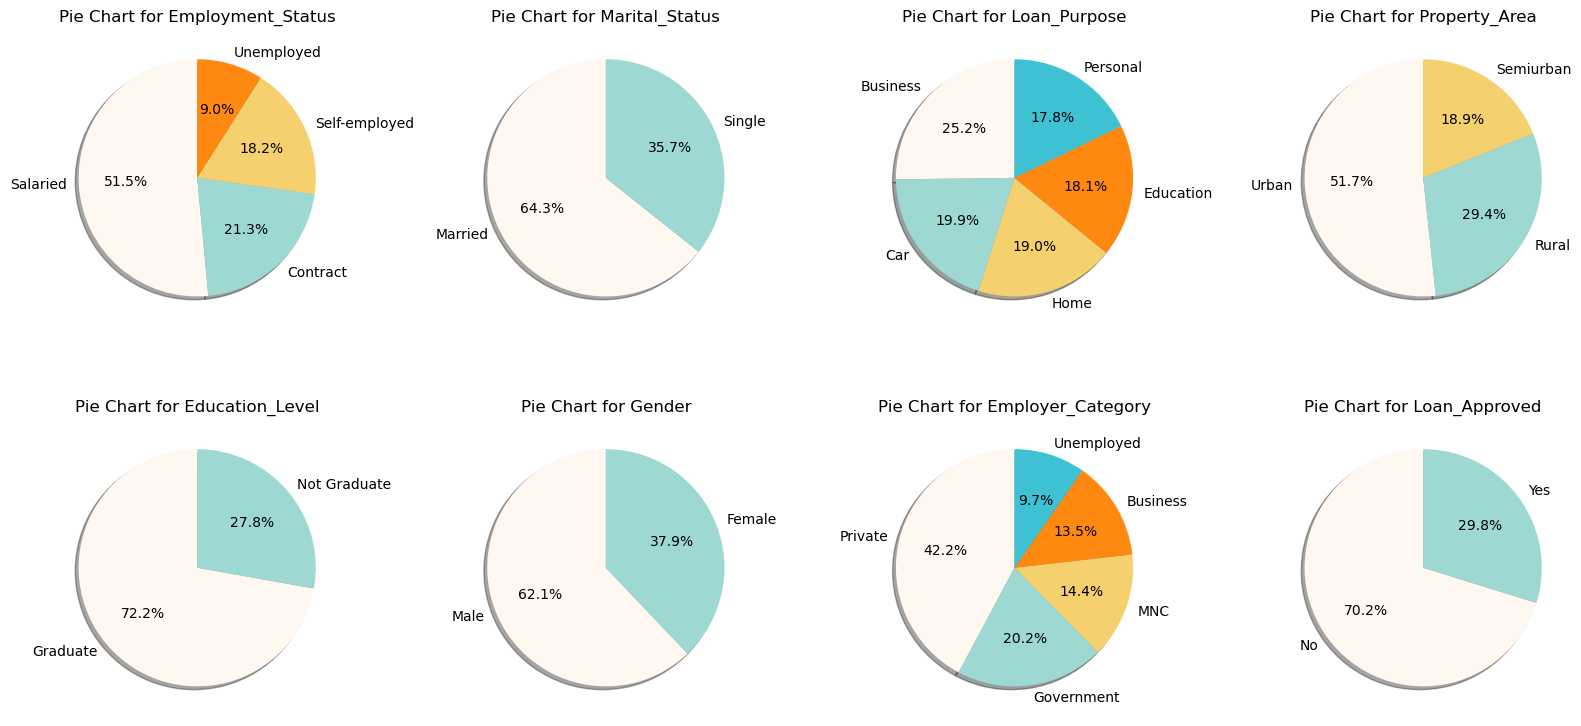

In [26]:
# Pie charts for all categorical columns in one figure with extended custom colors
import matplotlib.pyplot as plt

categorical_columns = [
    'Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
    'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'
]

# Extended custom color palette (added a matching teal)
custom_colors = ['#FFF8F0', '#9DD9D2', '#F4D06F', '#FF8811', '#3EC1D3']  # #3EC1D3 is a teal shade

n_cols = 4
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    values = df[col].value_counts()
    values.plot.pie(ax=axes[i], autopct='%1.1f%%', startangle=90,shadow=True,colors=custom_colors[:len(values)])
    axes[i].set_title(f'Pie Chart for {col}')
    axes[i].set_ylabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


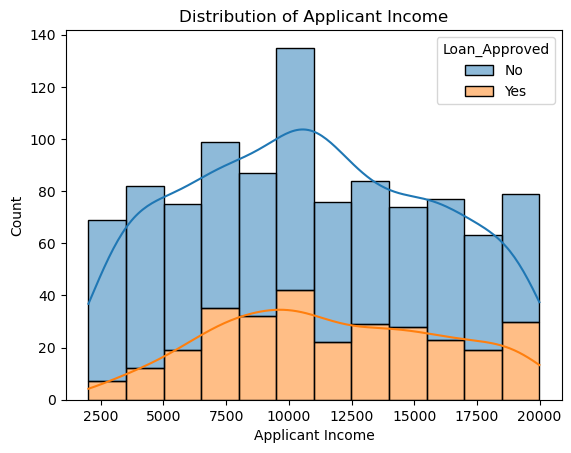

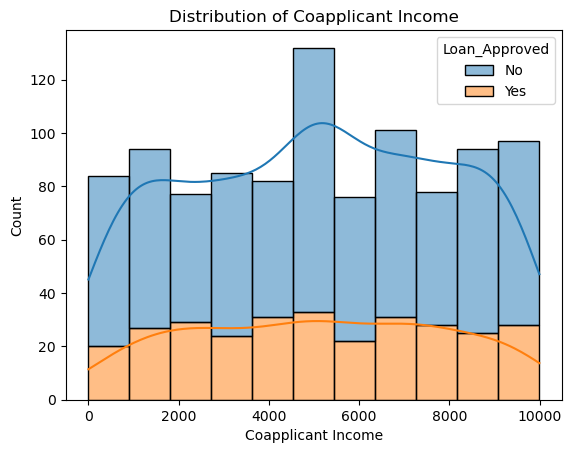

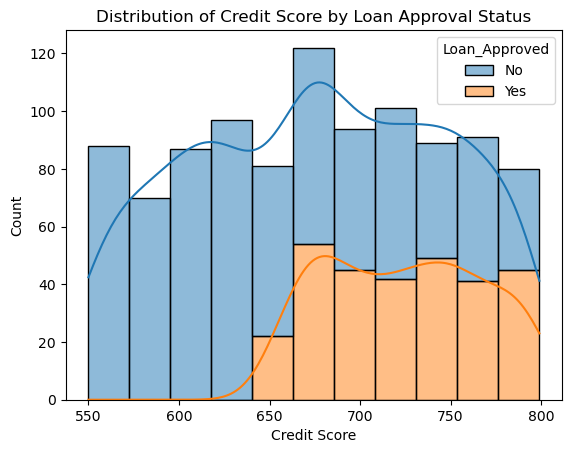

In [27]:
# Distribution of Applicant Income
sns.histplot(data=df, x='Applicant_Income', hue='Loan_Approved', kde=True, multiple='stack')
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Count')
plt.show()

# Distribution of Coapplicant Income
sns.histplot(data=df, x='Coapplicant_Income', hue='Loan_Approved', kde=True, multiple='stack')
plt.title('Distribution of Coapplicant Income')
plt.xlabel('Coapplicant Income')
plt.ylabel('Count')
plt.show()

# Distribution of Credit Score by Loan Approval Status
sns.histplot(data=df, x='Credit_Score', hue='Loan_Approved', kde=True, multiple='stack')
plt.title('Distribution of Credit Score by Loan Approval Status')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()


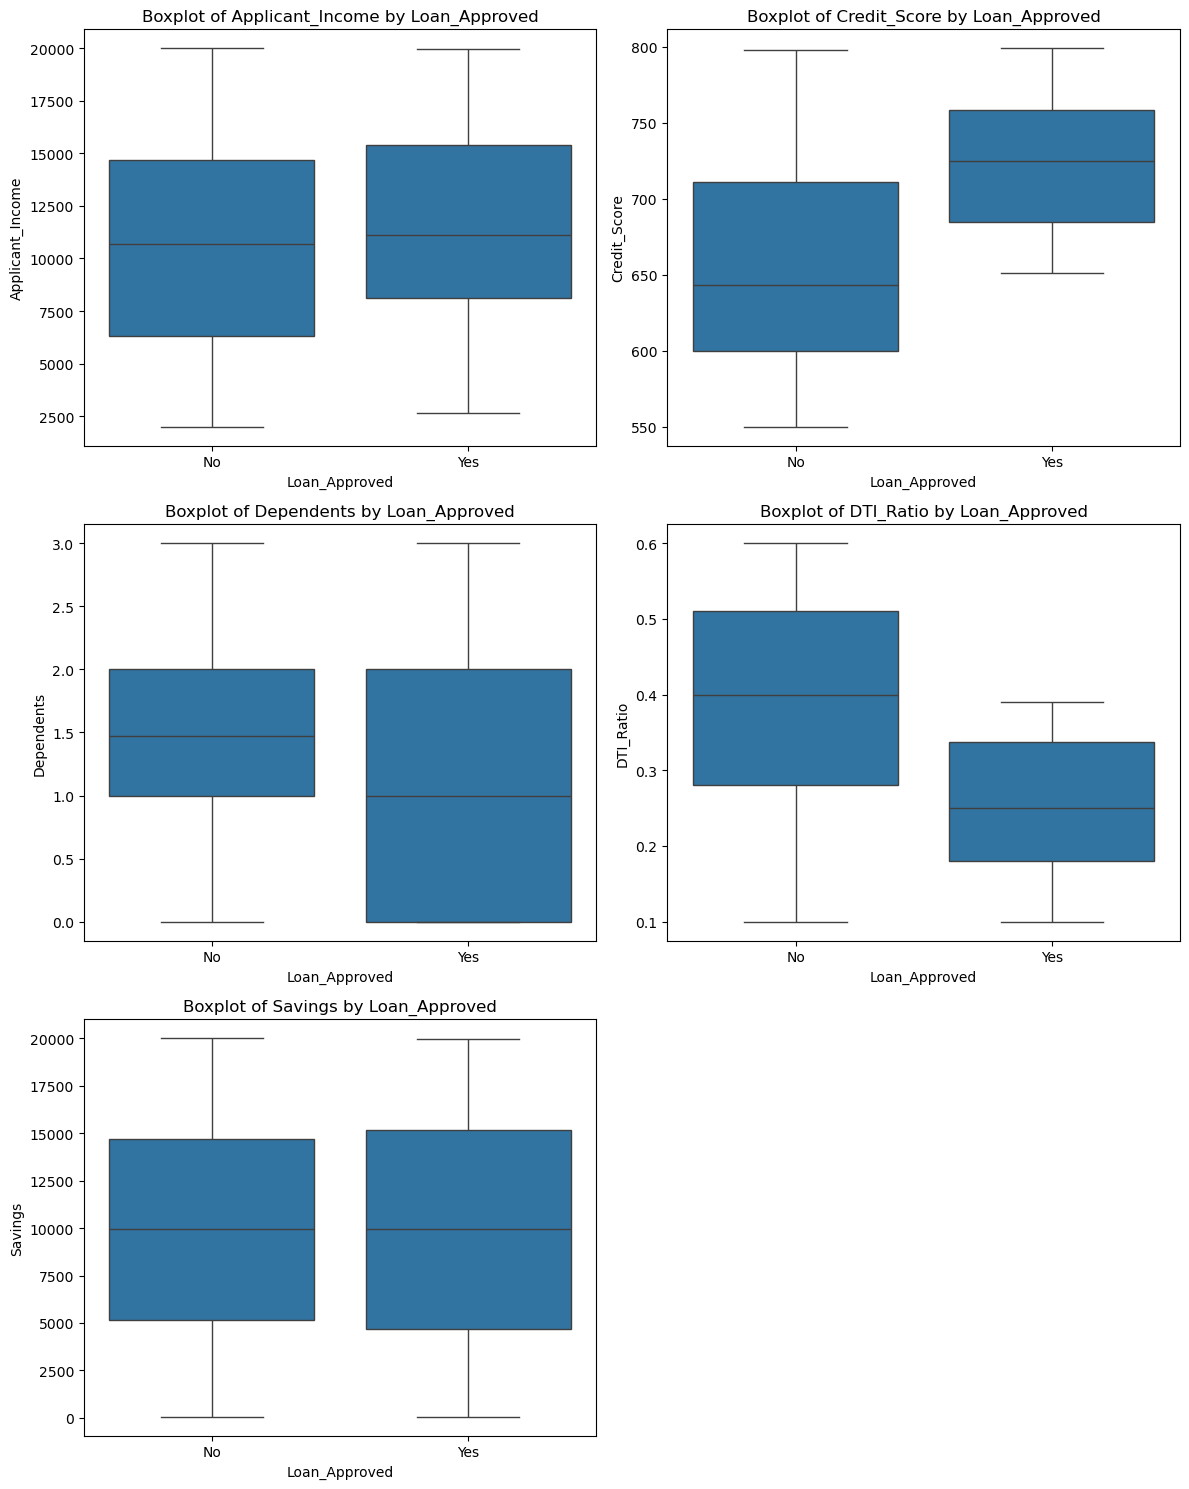

In [28]:
# Box plots for selected features by Loan_Approved
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Applicant_Income', 'Credit_Score', 'Dependents', 'DTI_Ratio', 'Savings']

n_cols = 2
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Loan_Approved', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} by Loan_Approved')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [29]:
df = df.drop(columns=['Applicant_ID'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [30]:
#encoding
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]
ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols))
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

<Axes: >

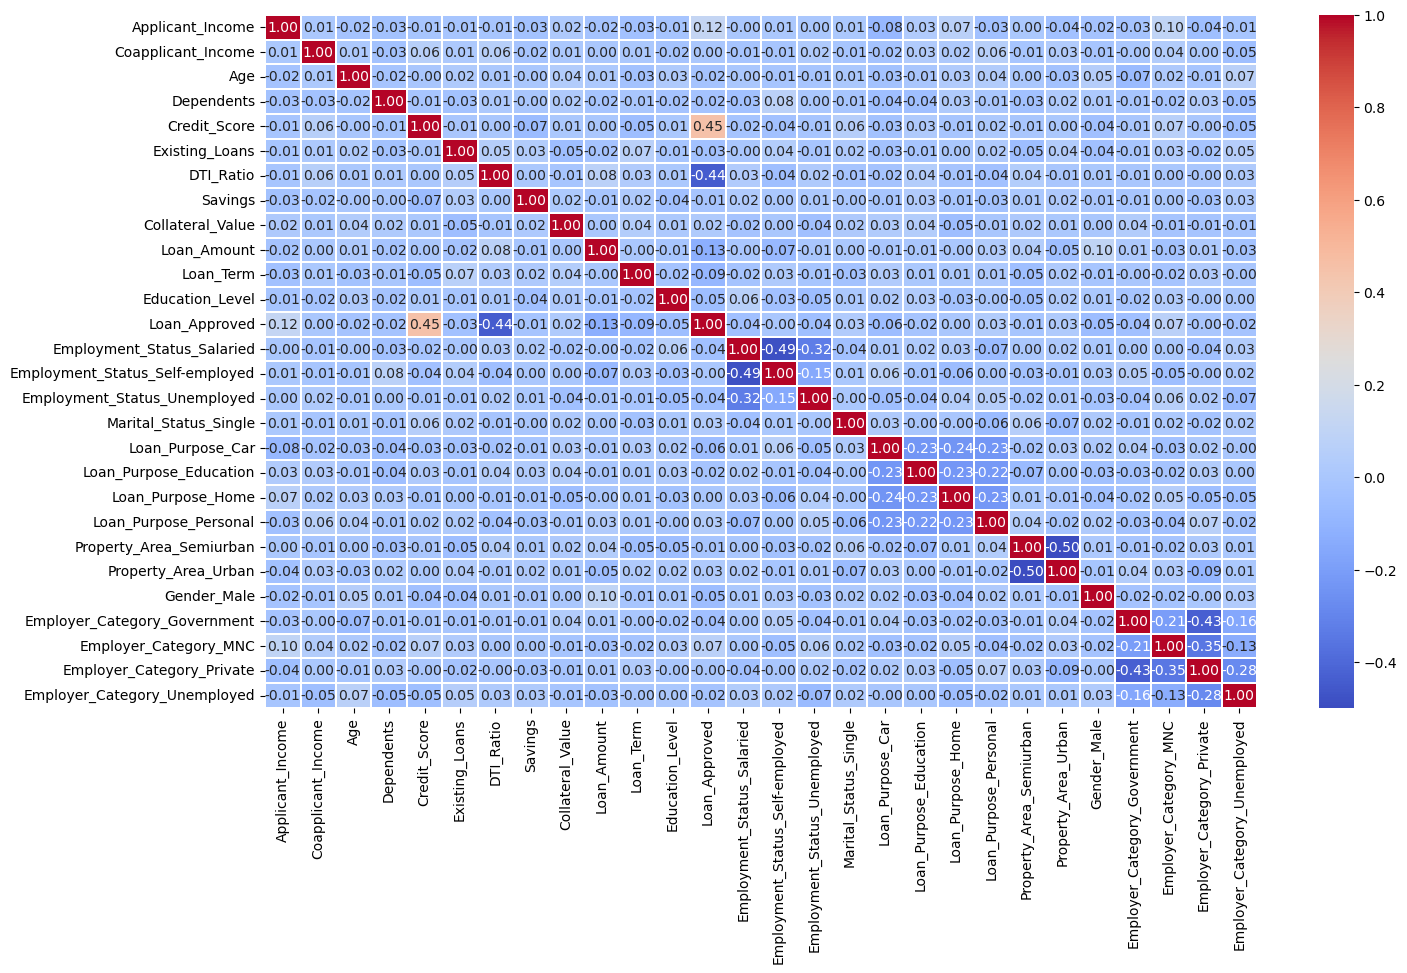

In [31]:
#correlation heatmap
num_cols = df.select_dtypes(include=['number']).columns
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(16,9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.10)

In [32]:
#train test split
X = df.drop(columns=['Loan_Approved'])
y = df['Loan_Approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
# Model evaluation loop before feature engineering

models = [
    ("Logistic Regression", LogisticRegression()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("Naive Bayes", GaussianNB())
]

for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} (Before Feature Engineering):")
    print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("-" * 30)



Logistic Regression (Before Feature Engineering):
Confusion Matrix: [[126  13]
 [ 14  47]]
Accuracy: 0.865
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 Score: 0.7768595041322314
------------------------------

KNN (Before Feature Engineering):
Confusion Matrix: [[120  19]
 [ 29  32]]
Accuracy: 0.76
Precision: 0.6274509803921569
Recall: 0.5245901639344263
F1 Score: 0.5714285714285714
------------------------------

Naive Bayes (Before Feature Engineering):
Confusion Matrix: [[128  11]
 [ 16  45]]
Accuracy: 0.865
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 Score: 0.7692307692307693
------------------------------


In [35]:
#feature engineering
df["DTI_Ratio_squared"] = df["DTI_Ratio"] ** 2
df["Credit_Score_squared"] = df["Credit_Score"] ** 2

df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

x = df.drop(columns=["Loan_Approved", "DTI_Ratio", "Credit_Score", "Applicant_Income"])
y = df["Loan_Approved"]
#tarina test split again after feature engineering
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
# Model evaluation loop after feature engineering
models = [
    ("Logistic Regression", LogisticRegression()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("Naive Bayes", GaussianNB())
]

for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} (After Feature Engineering):")
    print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("-" * 30)



Logistic Regression (After Feature Engineering):
Confusion Matrix: [[125  14]
 [ 12  49]]
Accuracy: 0.87
Precision: 0.7777777777777778
Recall: 0.8032786885245902
F1 Score: 0.7903225806451613
------------------------------

KNN (After Feature Engineering):
Confusion Matrix: [[119  20]
 [ 27  34]]
Accuracy: 0.765
Precision: 0.6296296296296297
Recall: 0.5573770491803278
F1 Score: 0.591304347826087
------------------------------

Naive Bayes (After Feature Engineering):
Confusion Matrix: [[128  11]
 [ 16  45]]
Accuracy: 0.865
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 Score: 0.7692307692307693
------------------------------
